# Preditor de Diabetes Gestacional
Classificação de pacientes com ou sem diabetes gestacional usando XGBoost.

## Importações
Todas as bibliotecas necessárias para executar o notebook do começo ao fim.

In [1]:
# Suprime todos os avisos para manter a saída limpa
import warnings
warnings.filterwarnings('ignore')

# Biblioteca para manipulação e leitura de dados tabulares
import pandas as pd

# Função para dividir os dados em treino e validação
from sklearn.model_selection import train_test_split

# Funções para calcular a acurácia e a matriz de confusão
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Biblioteca do algoritmo XGBoost
import xgboost as xgb

# Biblioteca para exibir gráficos
import matplotlib.pyplot as plt

# Biblioteca para salvar e carregar o modelo treinado
import joblib

## Etapa 1: Ingestão dos Dados
Carrega o arquivo CSV e separa a variável alvo (`diabetes`) das variáveis preditoras. A coluna `ID` é descartada por não ter valor preditivo.

In [2]:
# Carrega o arquivo CSV usando ponto e vírgula como separador de colunas
df = pd.read_csv('diabetes-gestacional.csv', sep=';')

# Exibe as primeiras linhas para conferir se os dados foram carregados corretamente
print('Primeiras linhas da base de dados:')
print(df.head())

# Exibe o total de registros e colunas
print(f'\nTotal de registros: {len(df)} | Total de colunas: {len(df.columns)}')

# Exibe a distribuição da variável alvo (quantas pacientes têm ou não diabetes)
print('\nDistribuição da variável alvo (diabetes):')
print(df['diabetes'].value_counts().rename({0: 'Sem diabetes (0)', 1: 'Com diabetes (1)'}))

# Separa a variável alvo (o que queremos prever)
y = df['diabetes']

# Separa as variáveis preditoras (remove a coluna ID e a variável alvo)
X = df.drop(columns=['ID', 'diabetes'])

# Exibe quais colunas serão usadas como preditoras
print('\nVariáveis preditoras:', list(X.columns))

Primeiras linhas da base de dados:
        ID  gravidez  glicose  pressao-arterial  espessura-triceps  insulina  \
0  1354778         0      171                80                 34        23   
1  1147438         8       92                93                 47        36   
2  1640031         7      115                47                 52        35   
3  1883350         9      103                78                 25       304   
4  1424119         1       85                59                 27        35   

   indice-massa-corporal  diabetes-pedigree  idade  diabetes  
0              43.509726           1.213191     21         0  
1              21.240576           0.158365     23         0  
2              41.511523           0.079019     23         0  
3              29.582192           1.282870     43         1  
4              42.604536           0.549542     22         0  

Total de registros: 10000 | Total de colunas: 10

Distribuição da variável alvo (diabetes):
diabetes
Sem 

## Etapa 2: Separação dos Dados
Divide a base em **80% para treino** e **20% para validação**. O parâmetro `random_state=42` garante que o sorteio seja sempre igual. O parâmetro `stratify=y` mantém a mesma proporção de pacientes com e sem diabetes nas duas partes.

In [3]:
# Divide os dados: 80% para treino e 20% para validação
# random_state=42 garante que o resultado seja o mesmo toda vez que o código for executado
# stratify=y mantém a proporção de 0s e 1s igual nas duas partes
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Exibe o tamanho de cada parte
print(f'Dados de treino:    {len(X_treino)} registros ({len(X_treino)/len(X):.0%})')
print(f'Dados de validação: {len(X_validacao)} registros ({len(X_validacao)/len(X):.0%})')

# Confirma que a proporção da variável alvo foi mantida nos dois conjuntos
print(f'\nProporção de diabetes no treino:    {y_treino.mean():.2%}')
print(f'Proporção de diabetes na validação: {y_validacao.mean():.2%}')

Dados de treino:    8000 registros (80%)
Dados de validação: 2000 registros (20%)

Proporção de diabetes no treino:    33.44%
Proporção de diabetes na validação: 33.45%


## Etapa 3: Treinamento do Algoritmo XGBoost
Cria e treina o modelo usando o algoritmo **XGBoost** (Extreme Gradient Boosting), que combina várias árvores de decisão para fazer previsões mais precisas.

In [4]:
# Cria o modelo XGBoost com semente aleatória fixa para reprodutibilidade
# verbosity=0 impede que mensagens técnicas apareçam durante o treino
modelo = xgb.XGBClassifier(random_state=42, verbosity=0)

# Treina o modelo usando os dados de treino
modelo.fit(X_treino, y_treino)

# Confirma que o treino terminou
print('Treinamento concluído!')

Treinamento concluído!


## Etapa 4: Validação do Resultado
Aplica o modelo treinado nos dados de validação (que ele nunca viu) e avalia o desempenho por meio da **acurácia** e da **matriz de confusão**.

Acurácia do modelo: 95.80%


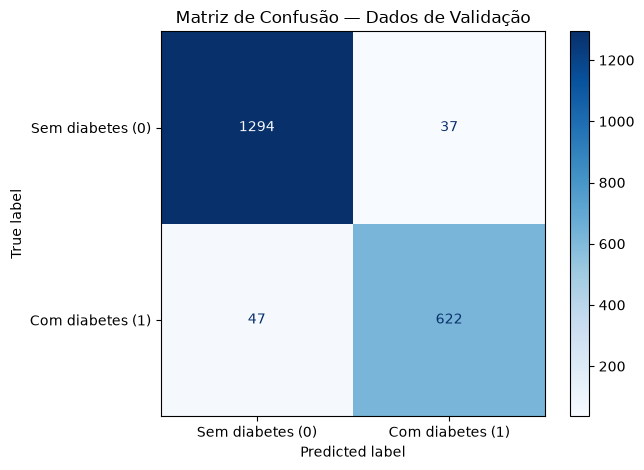


── Explicação da Matriz de Confusão ──────────────────────────────────────────
  Verdadeiros Negativos (VN) = 1294  →  pacientes SEM diabetes que o modelo ACERTOU  (previu 0, era 0)
  Falsos Positivos      (FP) =   37  →  pacientes SEM diabetes que o modelo ERROU    (previu 1, era 0)
  Falsos Negativos      (FN) =   47  →  pacientes COM diabetes que o modelo ERROU    (previu 0, era 1)
  Verdadeiros Positivos (VP) =  622  →  pacientes COM diabetes que o modelo ACERTOU  (previu 1, era 1)
──────────────────────────────────────────────────────────────────────────────
  Total de acertos: VN + VP = 1916 de 2000 (95.80%)


In [5]:
# Usa o modelo para prever os resultados dos dados de validação
y_previsto = modelo.predict(X_validacao)

# Calcula a acurácia: proporção de previsões corretas em relação ao total
acuracia = accuracy_score(y_validacao, y_previsto)
print(f'Acurácia do modelo: {acuracia:.2%}')

# Calcula a matriz de confusão comparando os valores reais com os previstos
mc = confusion_matrix(y_validacao, y_previsto)

# Exibe a matriz de confusão como gráfico
disp = ConfusionMatrixDisplay(
    confusion_matrix=mc,
    display_labels=['Sem diabetes (0)', 'Com diabetes (1)']
)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão — Dados de Validação')
plt.tight_layout()
plt.show()

# Extrai cada número da matriz de confusão para explicar individualmente
vn = mc[0, 0]
fp = mc[0, 1]
fn = mc[1, 0]
vp = mc[1, 1]

# Exibe a explicação de cada número da matriz de confusão
print('\n── Explicação da Matriz de Confusão ──────────────────────────────────────────')
print(f'  Verdadeiros Negativos (VN) = {vn:>4}  →  pacientes SEM diabetes que o modelo ACERTOU  (previu 0, era 0)')
print(f'  Falsos Positivos      (FP) = {fp:>4}  →  pacientes SEM diabetes que o modelo ERROU    (previu 1, era 0)')
print(f'  Falsos Negativos      (FN) = {fn:>4}  →  pacientes COM diabetes que o modelo ERROU    (previu 0, era 1)')
print(f'  Verdadeiros Positivos (VP) = {vp:>4}  →  pacientes COM diabetes que o modelo ACERTOU  (previu 1, era 1)')
print('──────────────────────────────────────────────────────────────────────────────')
print(f'  Total de acertos: VN + VP = {vn + vp} de {len(y_validacao)} ({(vn + vp)/len(y_validacao):.2%})')

## Salvando o Modelo Preditivo
Exporta o modelo treinado para o arquivo `preditor-diabetes.pkl`. Esse arquivo contém tudo o que é necessário para carregar e usar o modelo em outro programa, como uma interface gráfica.

In [6]:
# Salva o modelo treinado no arquivo preditor-diabetes.pkl
joblib.dump(modelo, 'preditor-diabetes.pkl')

# Confirma que o arquivo foi salvo com sucesso
print('Modelo salvo com sucesso em: preditor-diabetes.pkl')
print()
print('Para usar o modelo em outro programa, basta fazer:')
print("  import joblib")
print("  modelo = joblib.load('preditor-diabetes.pkl')")
print("  resultado = modelo.predict([[gravidez, glicose, pressao, triceps, insulina, imc, pedigree, idade]])")

Modelo salvo com sucesso em: preditor-diabetes.pkl

Para usar o modelo em outro programa, basta fazer:
  import joblib
  modelo = joblib.load('preditor-diabetes.pkl')
  resultado = modelo.predict([[gravidez, glicose, pressao, triceps, insulina, imc, pedigree, idade]])
